# A matrix model with SU(3) matrices

*Aug 30, 2026*

**[Javad Komijani](mailto:jkomijani@gmail.com)**

## Setup: a single SU(N) matrix

Consider a single random matrix $U \in \mathrm{SU}(N)$, distributed according to

$$
p(U) \propto \exp\left(\frac{\beta}{N} \mathrm{ReTr}(U)\right)
$$

with respect to the Haar measure on $\mathrm{SU}(N)$. This is as simple
as a lattice-gauge-theory-like model can get: a single link from a point back to itself with a
Wilson-loop-like action. It is a natural first target for a flow-based
sampler on a compact, non-abelian group.

**On the idea.** Applying flow-based models to $\mathrm{SU}(N)$-valued variables was first proposed in

> D. Boyda, G. Kanwar, S. Racanière, D. J. Rezende, M. S. Albergo, K. Cranmer,
> D. C. Hackett, and P. E. Shanahan,
> Phys. Rev. D **103**, 074504 (2021),
> [arXiv:2008.05456](https://arxiv.org/abs/2008.05456).

The particular parameterization of the SU(3) eigenvalues used below (in terms
of two angles, $\theta$ and $\phi$) follows

> J. Komijani and M. K. Marinković,
> [arXiv:2501.18288](https://arxiv.org/abs/2501.18288).

**On naming.** "Normalizing flow" carries two different readings of
"normalizing": flowing *to* a normal (Gaussian) distribution, or keeping
the density properly *normalized* at each step via the change-of-variables
Jacobian. Under the first reading the name is odd here: on a compact group
like $\mathrm{SU}(N)$ there is no Gaussian to normalize toward, and the
natural reference measure is the Haar measure instead -- exactly what the
flow below is trained to connect to $p(U)$. The second reading is
unaffected, since the Jacobian correction works the same way regardless of
the base measure. Names such as *trivializing flow* (echoing Lüscher's
*trivializing maps*, M. Lüscher, Commun. Math. Phys. **293**, 899 (2010),
[arXiv:0907.5491](https://arxiv.org/abs/0907.5491)), *Haarizing flow*, or
*uniformizing flow* would describe the compact-group case more precisely
than the Gaussian-flavored reading of "normalizing flow".

In [1]:
import torch
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["text.usetex"] = True

In [2]:
if torch.cuda.is_available():                                                   
    torch.set_default_device('cuda')

grab = lambda x: x.detach().cpu().numpy()

### Set up a module for transformation

The general recipe for building a flow on a Lie group is:
1. parameterize the eigenvalues of a group element with a handful of real parameters,
2. run an ordinary real-valued flow on those parameters (here, a rational quadratic spline, `RQSplineNet_`),
3. map back to the group.

`MatrixModule_` implements this recipe given a `matrix_handle` that knows how to go back and forth
between $\mathrm{SU}(N)$ and its coordinates: one angle $\theta$ for SU(2),
two angles $\theta$ and $\phi$ for SU(3), following the parameterization
cited above. For a discussion on parameterization see [arXiv:2501.18288](https://arxiv.org/abs/2501.18288).

In [3]:
from normflow.nn import MultiChannelModule_
from normflow.nn import MatrixModule_
from normflow.nn import RQSplineNet_

from normflow.lib.matrix_handles import SU2MatrixParametrizer
from normflow.lib.matrix_handles import SU3MatrixParametrizer


def assemble_net_su2(num_spline_knots: int):
    """
    Build a network using one RQ spline for one angle (θ).
    """
    param_net_ = RQSplineNet_(num_spline_knots)
    matrix_handle = SU2MatrixParametrizer()
    return MatrixModule_(param_net_, matrix_handle=matrix_handle)


def assemble_net_su3(num_spline_knots: int):
    """
    Build a network using two RQ spline for two angles (θ, φ).
    """
    net_theta_ = RQSplineNet_(num_spline_knots)    
    net_phi_ = RQSplineNet_(1 + num_spline_knots // 2, symmetric=True)
    param_net_ = MultiChannelModule_([net_theta_, net_phi_], channels_axis=-1)
    matrix_handle = SU3MatrixParametrizer()
    return MatrixModule_(param_net_, matrix_handle=matrix_handle)

### Put components together to make a model

1. `UniformSUnPrior` draws from the Haar measure on $\mathrm{SU}(N)$ -- the reference distribution the flow starts from.
2. `MatrixModule_` implements the transformation.
3. `MatrixAction` implements the action $S(U) = -\frac{\beta}{N}\mathrm{ReTr}(U)$ defined above.
4. `Model` bundles the network, prior, and action together and can train the network by minimizing the reverse KL divergence between the flow's output and $p(U) \propto e^{-S(U)}$ -- no training data required.

In [4]:
from normflow import Model

from normflow.action import MatrixAction

from normflow.prior import UniformSUnPrior

In [5]:
def make_normflow_model(n_c, beta, num_spline_knots):
    """The main function for building the model."""
    
    # Define the prior distribution
    prior = UniformSUnPrior(n=n_c)
    
    # Define the action
    action = MatrixAction(beta=beta)
    
    # Initialize the neural network for transformations
    if n_c == 2:
        net_ = assemble_net_su2(num_spline_knots)
    elif n_c == 3:
        net_ = assemble_net_su3(num_spline_knots)
    else:
        raise ValueError(f"n_c = {n_c} is not implemented")
    
    # Create the Model with the defined components
    model = Model(network_fn_=net_, prior=prior, action=action)
    
    return model

In [6]:
# Action parameters
n_c = 3
beta = 6

# Instantiate the model
model = make_normflow_model(n_c=n_c, beta=beta, num_spline_knots=10)

In [7]:
load_pretrained_model = True

if load_pretrained_model:

    assert n_c == 3, "The pretrained model is for SU(3)"
    
    weights_blob = 'UEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAQABIAYXJjaGl2ZS9kYXRhLnBrbEZCDgBaWlpaWlpaWlpaWlpaWoACY2NvbGxlY3Rpb25zCk9yZGVyZWREaWN0CnEAKVJxAShYFgAAAHBhcmFtX25ldF8uMC53ZWlnaHRzX3hxAmN0b3JjaC5fdXRpbHMKX3JlYnVpbGRfdGVuc29yX3YyCnEDKChYBwAAAHN0b3JhZ2VxBGN0b3JjaApGbG9hdFN0b3JhZ2UKcQVYAQAAADBxBlgDAAAAY3B1cQdLCXRxCFFLAEsJhXEJSwGFcQqJaAApUnELdHEMUnENWBYAAABwYXJhbV9uZXRfLjAud2VpZ2h0c195cQ5oAygoaARoBVgBAAAAMXEPaAdLCXRxEFFLAEsJhXERSwGFcRKJaAApUnETdHEUUnEVWBYAAABwYXJhbV9uZXRfLjAud2VpZ2h0c19kcRZoAygoaARoBVgBAAAAMnEXaAdLCnRxGFFLAEsKhXEZSwGFcRqJaAApUnEbdHEcUnEdWBYAAABwYXJhbV9uZXRfLjEud2VpZ2h0c194cR5oAygoaARoBVgBAAAAM3EfaAdLBXRxIFFLAEsFhXEhSwGFcSKJaAApUnEjdHEkUnElWBYAAABwYXJhbV9uZXRfLjEud2VpZ2h0c195cSZoAygoaARoBVgBAAAANHEnaAdLBXRxKFFLAEsFhXEpSwGFcSqJaAApUnErdHEsUnEtWBYAAABwYXJhbV9uZXRfLjEud2VpZ2h0c19kcS5oAygoaARoBVgBAAAANXEvaAdLBnRxMFFLAEsGhXExSwGFcTKJaAApUnEzdHE0UnE1dX1xNlgJAAAAX21ldGFkYXRhcTdoAClScTgoWAAAAABxOX1xOlgHAAAAdmVyc2lvbnE7SwFzWAoAAABwYXJhbV9uZXRfcTx9cT1oO0sBc1gMAAAAcGFyYW1fbmV0Xy4wcT59cT9oO0sBc1gUAAAAcGFyYW1fbmV0Xy4wLnNvZnRtYXhxQH1xQWg7SwFzWBUAAABwYXJhbV9uZXRfLjAuc29mdHBsdXNxQn1xQ2g7SwFzWAwAAABwYXJhbV9uZXRfLjFxRH1xRWg7SwFzWBQAAABwYXJhbV9uZXRfLjEuc29mdG1heHFGfXFHaDtLAXNYFQAAAHBhcmFtX25ldF8uMS5zb2Z0cGx1c3FIfXFJaDtLAXN1c2IuUEsHCJUU7tZWAwAAVgMAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAAFwAlAGFyY2hpdmUvLmZvcm1hdF92ZXJzaW9uRkIhAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWjFQSwcIt+/cgwEAAAABAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAaADcAYXJjaGl2ZS8uc3RvcmFnZV9hbGlnbm1lbnRGQjMAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaNjRQSwcIP3dx6QIAAAACAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAARAD8AYXJjaGl2ZS9ieXRlb3JkZXJGQjsAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpsaXR0bGVQSwcIhT3jGQYAAAAGAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAOAD4AYXJjaGl2ZS9kYXRhLzBGQjoAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWv1Gyz6KocI+X/yxPoRxlD6xlVg+JeKjPUOD8b3Cl6a+UQPwvlBLBwirSq1UJAAAACQAAABQSwMEAAAICAAAAAAAAAAAAAAAAAAAAAAAAA4AIABhcmNoaXZlL2RhdGEvMUZCHABaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpa3xK5vlfzqb5u7Je+fVt0vvyzE753nAC9rG/APbkAhz7D/ds+UEsHCIj14bUkAAAAJAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADgAgAGFyY2hpdmUvZGF0YS8yRkIcAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWloS/nm9yXCBv4HZeL+Z71C/zGQOvwwHKb6XSNU+pR6eP/cNCUDr9NI/UEsHCDbF0g0oAAAAKAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADgAcAGFyY2hpdmUvZGF0YS8zRkIYAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWpKXWTyqchs8VI27OlS6R7x9PY68UEsHCA3YV+YUAAAAFAAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAADgAwAGFyY2hpdmUvZGF0YS80RkIsAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaihpCvFKluLveK6Y7hOUpPBATYDxQSwcI6YMhyxQAAAAUAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAOADAAYXJjaGl2ZS9kYXRhLzVGQiwAWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlrz0nq9MWxQvbcht7xd9oA8t0VpPYWbfj1QSwcIraEuWhgAAAAYAAAAUEsDBAAACAgAAAAAAAAAAAAAAAAAAAAAAAAPACsAYXJjaGl2ZS92ZXJzaW9uRkInAFpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWjMKUEsHCNGeZ1UCAAAAAgAAAFBLAwQAAAgIAAAAAAAAAAAAAAAAAAAAAAAAHgAyAGFyY2hpdmUvLmRhdGEvc2VyaWFsaXphdGlvbl9pZEZCLgBaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaWlpaMTExMTg5NzkxMTA1NTMwMjYxMDEwMDA2OTM2ODk5MzQ1ODUyOTQ2MFBLBwjaYawVKAAAACgAAABQSwECAAAAAAgIAAAAAAAAlRTu1lYDAABWAwAAEAAAAAAAAAAAAAAAAAAAAAAAYXJjaGl2ZS9kYXRhLnBrbFBLAQIAAAAACAgAAAAAAAC379yDAQAAAAEAAAAXAAAAAAAAAAAAAAAAAKYDAABhcmNoaXZlLy5mb3JtYXRfdmVyc2lvblBLAQIAAAAACAgAAAAAAAA/d3HpAgAAAAIAAAAaAAAAAAAAAAAAAAAAABEEAABhcmNoaXZlLy5zdG9yYWdlX2FsaWdubWVudFBLAQIAAAAACAgAAAAAAACFPeMZBgAAAAYAAAARAAAAAAAAAAAAAAAAAJIEAABhcmNoaXZlL2J5dGVvcmRlclBLAQIAAAAACAgAAAAAAACrSq1UJAAAACQAAAAOAAAAAAAAAAAAAAAAABYFAABhcmNoaXZlL2RhdGEvMFBLAQIAAAAACAgAAAAAAACI9eG1JAAAACQAAAAOAAAAAAAAAAAAAAAAALQFAABhcmNoaXZlL2RhdGEvMVBLAQIAAAAACAgAAAAAAAA2xdINKAAAACgAAAAOAAAAAAAAAAAAAAAAADQGAABhcmNoaXZlL2RhdGEvMlBLAQIAAAAACAgAAAAAAAAN2FfmFAAAABQAAAAOAAAAAAAAAAAAAAAAALgGAABhcmNoaXZlL2RhdGEvM1BLAQIAAAAACAgAAAAAAADpgyHLFAAAABQAAAAOAAAAAAAAAAAAAAAAACQHAABhcmNoaXZlL2RhdGEvNFBLAQIAAAAACAgAAAAAAACtoS5aGAAAABgAAAAOAAAAAAAAAAAAAAAAAKQHAABhcmNoaXZlL2RhdGEvNVBLAQIAAAAACAgAAAAAAADRnmdVAgAAAAIAAAAPAAAAAAAAAAAAAAAAACgIAABhcmNoaXZlL3ZlcnNpb25QSwECAAAAAAgIAAAAAAAA2mGsFSgAAAAoAAAAHgAAAAAAAAAAAAAAAACSCAAAYXJjaGl2ZS8uZGF0YS9zZXJpYWxpemF0aW9uX2lkUEsGBiwAAAAAAAAAHgMtAAAAAAAAAAAADAAAAAAAAAAMAAAAAAAAAPsCAAAAAAAAOAkAAAAAAABQSwYHAAAAADMMAAAAAAAAAQAAAFBLBQYAAAAADAAMAPsCAAA4CQAAAAA='
    model.net_.set_weights_blob(weights_blob)
    
else:
    
    model.train(n_epochs=2000, batch_size=128)

In [8]:
# Compute and print Effective Sample Size (ESS)
ess = model.compute_metrics(batch_size=1024)[0]                       
print(f"\nESS: {ess}\n")


ESS: 0.9998750686645508



In [9]:
if not load_pretrained_model:
    
    fig, axs = plt.subplots(1, 1, figsize=(6, 4))

    log_dict = model.trainer.logger.load_numpy()
    plt.plot(log_dict['epoch'], log_dict['loss'], '-')

## Illustrate the eigenangles

The eigenvalues of $U \in \mathrm{SU}(N)$ lie on the unit circle with product
fixed to 1; their phases (eigenangles) are gauge-invariant observables. For
SU(3) with the action above, the marginal distribution of a single eigenangle
has a known closed form (`su3_phase_marginal_dist`), giving us a clean,
independent check of the trained flow.

In [10]:
from normflow.lib.matrix_handles import su3_phase_marginal_dist

from lattice_ml.linalg import eigu

In [11]:
# Sample from the trained model
# As ESS is close to 1, we neglect any bias corrections

x, logr = model.prior.sample_(batch_size=1024 * 128)

with torch.no_grad():
    y, logj = model.network_fn_(x)

angles_x = grab(torch.angle(eigu(x)[0]))
angles_y = grab(torch.angle(eigu(y)[0]))

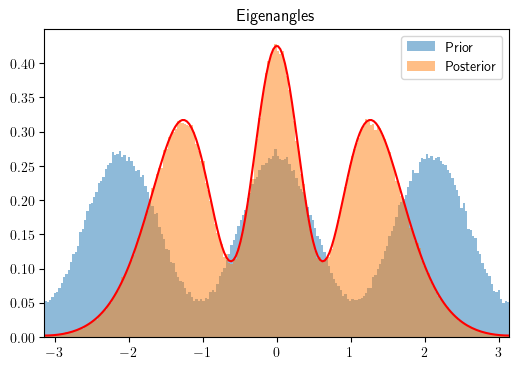

In [12]:
fig, axs = plt.subplots(1, 1, figsize=(6, 4))

plt.hist(angles_x.ravel(), density=True, bins=200, alpha=0.5, label='Prior')
plt.hist(angles_y.ravel(), density=True, bins=200, alpha=0.5, label='Posterior')
plt.xlim([-torch.pi, torch.pi])
plt.title("Eigenangles")
plt.legend()


# Add analytic results for SU(3)
x_0, pdf_0 = su3_phase_marginal_dist(model.action, bins=200)
x_0, pdf_0 = grab(x_0), grab(pdf_0)
plt.plot(x_0, pdf_0, color='r');

## Plot log-probabilities

A standard diagnostic for a trained flow: plot $\log q(y) = \log r(x) -
\log J$ (the flow's own log-density) against $\log p(y) = -S(y)$ (the target,
up to normalization) for samples $y$ drawn from the flow. A well-trained flow
should place these points along a single diagonal line, $\log p = \log q +
\text{const}$, with a small scatter around it -- consistent with the ESS
computed above.

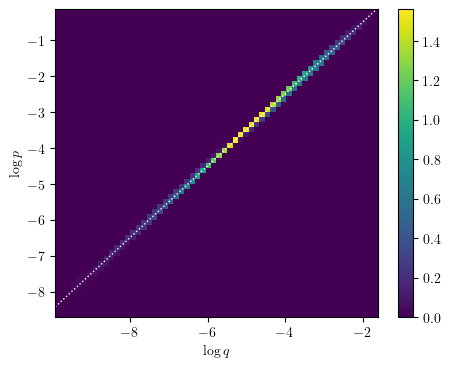

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(5.2, 4))

logq = logr - logj
logp = - model.action(y)

plt.hist2d(grab(logq), grab(logp), bins=60, density=True)
plt.xlabel(r'$\log q$')
plt.ylabel(r'$\log p$')
plt.colorbar()

    
# Diagonal: logp = logq + constant 
xmin = logq.min()
xmax = logq.max()

shift = logp.mean() - logq.mean()
plt.plot([xmin, xmax], [xmin + shift, xmax + shift], 'w:', linewidth=1);

# fig.savefig("SU3_logq_logp.pdf", dpi=600)